# PHASE 2: Data Cleaning & Quality Checks
**Traceability**
- Issue ID: #2 Data Cleaning & Quality Checks

**External References**:
- [Wassim Derbel - NASA Predictive Maintenance](https://www.kaggle.com/code/wassimderbel/nasa-predictive-maintenance-rul) (Constant Sensor Removal)
- [Carl Kirstein - Predictive Maintenance](https://www.kaggle.com/code/carlkirstein/predictive-maintenance-nasa-turbofan-regression) (Outlier Handling)

## 1. Objectives
- **Diagnostic**: Identify sensors with zero variance (constant).
- **Action**: Remove constant sensors to reduce dimensionality.
- **Diagnostic**: Detect outliers using statistical distribution plots.
- **Action**: Clip outliers to 1st/99th percentiles to preserve temporal continuity.

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Plotting Config ───────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})
COLORS = ['#1F4E79', '#2E75B6', '#70AD47', '#FF7043', '#AB47BC']

# ── Reproducibility Config ──────────────────────────────────────────────
np.random.seed(42)

# ── Global Config ────────────────────────────────────────────────────────
DATA_DIR = Path('../data')
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

COL_NAMES = (
    ['unit_number', 'time_cycles'] +
    ['setting_1', 'setting_2', 'setting_3'] +
    [f's_{i}' for i in range(1, 22)]   # s_1 ... s_21
)

### 2.1 Load Raw Data
Load the raw training and test data.

In [9]:
df_train = pd.read_csv(DATA_DIR / 'train_FD001.txt', sep=r'\s+', header=None, index_col=False, names=COL_NAMES)
df_test = pd.read_csv(DATA_DIR / 'test_FD001.txt', sep=r'\s+', header=None, index_col=False, names=COL_NAMES)
print(f"✅ Data loaded: Train {df_train.shape}, Test {df_test.shape}")

✅ Data loaded: Train (20631, 26), Test (13096, 26)


### 2.2 Diagnostic: Sensor Variance Analysis
We visualize the standard deviation of each sensor to identify those that do not change over time (constant sensors). These provide no predictive value.

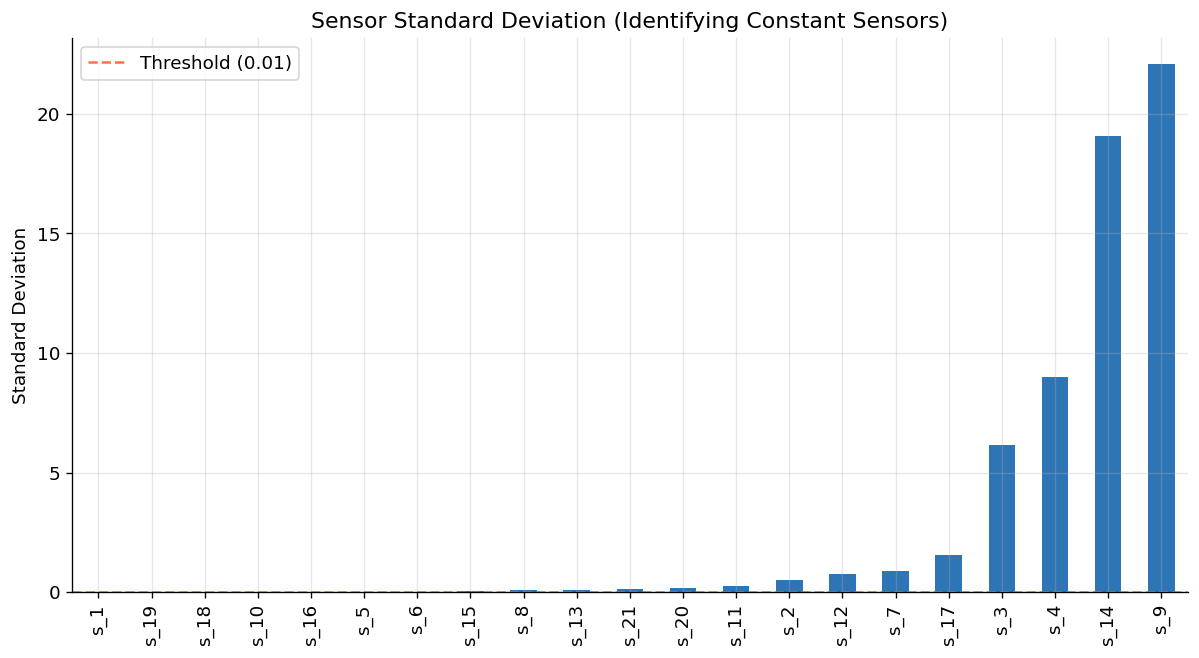

In [10]:
def visualize_sensor_variance(df, threshold=0.01):
    """Visualize the standard deviation of each sensor."""
    sensor_cols = [f's_{i}' for i in range(1, 22)]
    sensor_std = df[sensor_cols].std().sort_values()
    
    plt.figure(figsize=(12, 6))
    colors = [COLORS[3] if std < threshold else COLORS[1] for std in sensor_std]
    sensor_std.plot(kind='bar', color=colors)
    plt.axhline(y=threshold, color=COLORS[3], linestyle='--', label=f'Threshold ({threshold})')
    plt.title('Sensor Standard Deviation (Identifying Constant Sensors)')
    plt.ylabel('Standard Deviation')
    plt.legend()
    plt.show()
    
    return sensor_std[sensor_std < threshold].index.tolist()

constant_sensors = visualize_sensor_variance(df_train)

**Reasoning**: The bar chart clearly shows several sensors (highlighted in orange) have near-zero variance. We can safely drop them.

In [11]:
print(f"🔍 Constant sensors to drop (std < 0.01): {constant_sensors}")

df_train = df_train.drop(columns=constant_sensors)
df_test = df_test.drop(columns=constant_sensors)

remaining_sensors = [c for c in df_train.columns if c.startswith('s_')]
print(f"✅ Dropped {len(constant_sensors)} sensors. Remaining: {len(remaining_sensors)}")

🔍 Constant sensors to drop (std < 0.01): ['s_1', 's_19', 's_18', 's_10', 's_16', 's_5', 's_6']
✅ Dropped 7 sensors. Remaining: 14


### 2.3 Diagnostic: Outlier Detection
We examine the distribution of a representative sensor (e.g., `s_9`) to check for extreme outliers that might skew the model.

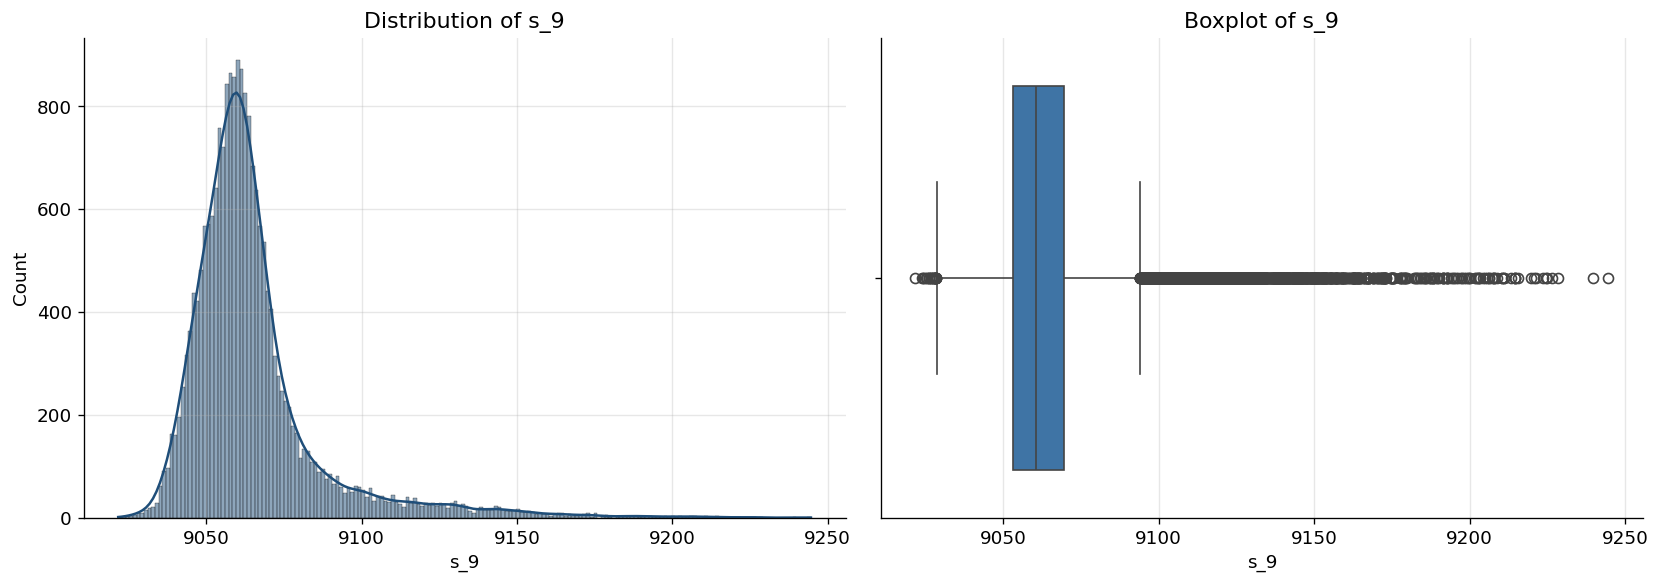

In [12]:
def visualize_outliers(df, sensor_col):
    """Visualize distribution and boxplot for a sensor."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.histplot(df[sensor_col], kde=True, ax=ax1, color=COLORS[0])
    ax1.set_title(f'Distribution of {sensor_col}')
    
    sns.boxplot(x=df[sensor_col], ax=ax2, color=COLORS[1])
    ax2.set_title(f'Boxplot of {sensor_col}')
    
    plt.tight_layout()
    plt.show()

visualize_outliers(df_train, 's_9')

**Reasoning**: The boxplot likely shows points outside the whiskers. We will clip values to the 1st and 99th percentiles to mitigate this without deleting rows (which would break time series).

--- Verification: Distribution After Clipping ---


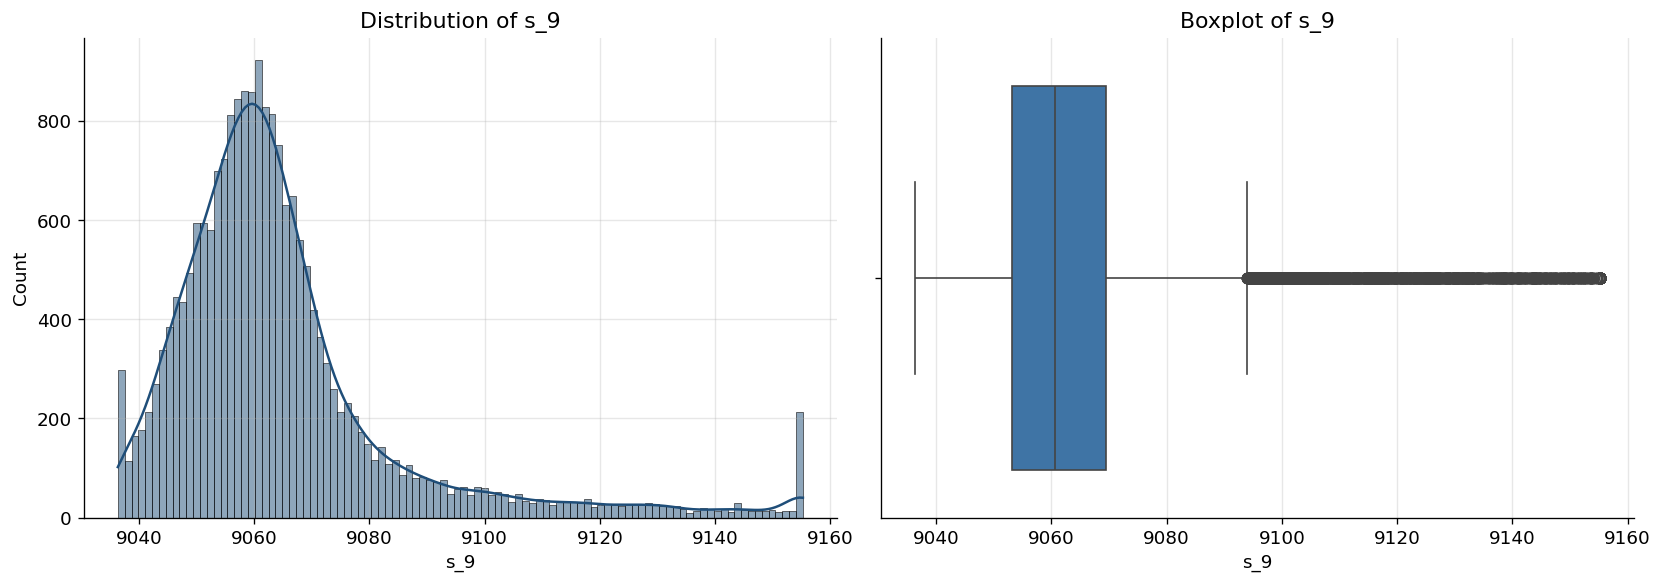

In [13]:
def handle_outliers(df, sensor_cols):
    """Clip outliers to 1st and 99th percentiles (preserve temporal continuity)."""
    df_clipped = df.copy()
    for col in sensor_cols:
        q1, q3 = df_clipped[col].quantile(0.01), df_clipped[col].quantile(0.99)
        df_clipped[col] = df_clipped[col].clip(lower=q1, upper=q3)
    return df_clipped

# Apply Clipping
df_train = handle_outliers(df_train, remaining_sensors)
df_test = handle_outliers(df_test, remaining_sensors)

# Verify Effect
print("--- Verification: Distribution After Clipping ---")
visualize_outliers(df_train, 's_9')

### 2.4 Final Scale Check
Verify the range of sensors after cleaning.

In [14]:
desc_stats = df_train[remaining_sensors].describe().T
print(desc_stats[['mean', 'std', 'min', 'max']])

# Save
df_train.to_csv(PROCESSED_DIR / 'train_cleaned.csv', index=False)
df_test.to_csv(PROCESSED_DIR / 'test_cleaned.csv', index=False)
print(f"\n✅ Cleaned data saved to {PROCESSED_DIR}")

             mean        std        min         max
s_2    642.680751   0.493480   641.6500   643.93000
s_3   1590.519824   6.037949  1577.6130  1605.87100
s_4   1408.927477   8.906258  1391.8830  1431.51700
s_7    553.368224   0.874390   551.1600   555.07000
s_8   2388.096533   0.069961  2387.9600  2388.29000
s_9   9065.036693  20.812184  9036.3500  9155.23900
s_11    47.540997   0.264366    47.0500    48.21000
s_12   521.414000   0.729302   519.5500   522.80000
s_13  2388.096042   0.070674  2387.9600  2388.29000
s_14  8143.580421  17.936673  8115.4160  8220.02000
s_15     8.442128   0.037025     8.3685     8.53507
s_17   393.207891   1.532668   390.0000   397.00000
s_20    38.816492   0.178232    38.3700    39.18000
s_21    23.289753   0.106904    23.0195    23.50884

✅ Cleaned data saved to ../data/processed
